<a href="https://colab.research.google.com/github/ajmalbiju56/ML/blob/main/housezip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# EDA (exploratory data analysis)
* Feature Engineering
* Model Building
* Perfomance validation

In [ ]:
#install
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 4.7 MB/s eta 0:00:00


In [ ]:
#libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler
pd.options.mode.copy_on_write = True

In [ ]:
pd.set_option('display.max_columns',None)
df=pd.read_csv("/content/drive/MyDrive/80111.csv",low_memory=False)
print(df)

    id      price  sqft_living  bedrooms  bathrooms  year_built  zipcode  \
0    1  1249000.0       6209.0         5        5.0        1986    80111   
1    2   220000.0       1422.0         5        4.0        1986    80111   
2    3  1250000.0       5614.0         2        3.0        1981    80111   
3    4   599900.0       2785.0         4        3.0        1982    80111   
4    5   986950.0       3449.0         6        4.0        2019    80111   
..  ..        ...          ...       ...        ...         ...      ...   
61  62  1470000.0       5292.0         5        4.0        1981    80111   
62  63   661559.0       3049.0         4        4.0        2018    80111   
63  64   715000.0       3593.0         5        3.0        1977    80111   
64  65   524900.0       2334.0         4        3.0        1978    80111   
65  66   677544.0       2641.0         4        3.5        1978    80111   

                        address   Latitude   Longitude  
0          Centennial, CO 8011

# New Section

In [ ]:
df.shape

(66, 10)

In [ ]:
df.tail(10)

,id,price,sqft_living,bedrooms,bathrooms,year_built,zipcode,address,Latitude,Longitude
56,57,518000.0,3402.0,6,3.0,1963,80111,"Centennial, CO 80111",39.616672,-104.874651
57,58,999800.0,5273.0,5,4.0,1991,80111,"Englewood, CO 80111",39.616672,-104.874651
58,59,1124950.0,3258.0,3,2.0,2019,80111,"Centennial, CO 80111",39.616672,-104.874651
59,60,875000.0,3307.0,5,5.0,1994,80111,"Englewood, CO 80111",39.616672,-104.874651
60,61,850000.0,4147.0,3,3.0,1994,80111,"Englewood, CO 80111",39.616672,-104.874651
61,62,1470000.0,5292.0,5,4.0,1981,80111,"Greenwood Village, CO 80111",39.616672,-104.874651
62,63,661559.0,3049.0,4,4.0,2018,80111,"Centennial, CO 80111",39.616672,-104.874651
63,64,715000.0,3593.0,5,3.0,1977,80111,"Greenwood Village, CO 80111",39.616672,-104.874651
64,65,524900.0,2334.0,4,3.0,1978,80111,"Englewood, CO 80111",39.616672,-104.874651
65,66,677544.0,2641.0,4,3.5,1978,80111,"Englewood, CO 80111",39.616672,-104.874651


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           66 non-null     int64  
 1   price        66 non-null     float64
 2   sqft_living  66 non-null     float64
 3   bedrooms     66 non-null     int64  
 4   bathrooms    66 non-null     float64
 5   year_built   66 non-null     int64  
 6   zipcode      66 non-null     int64  
 7   address      66 non-null     object 
 8   Latitude     66 non-null     float64
 9   Longitude    66 non-null     float64
dtypes: float64(5), int64(4), object(1)
memory usage: 5.3+ KB


In [ ]:
df.describe()

,id,price,sqft_living,bedrooms,bathrooms,year_built,zipcode,Latitude,Longitude
count,66.000000,6.600000e+01,66.000000,66.000000,66.000000,66.000000,66.0,6.600000e+01,6.600000e+01
mean,33.500000,8.049797e+05,3623.451515,3.636364,3.248485,1994.090909,80111.0,3.961667e+01,-1.048747e+02
std,19.196354,3.915756e+05,4239.300843,1.320097,1.114829,18.709707,0.0,2.863950e-14,1.288778e-13
min,1.000000,1.825000e+05,658.000000,1.000000,1.000000,1960.000000,80111.0,3.961667e+01,-1.048747e+02
25%,17.250000,5.842618e+05,2403.900000,2.250000,3.000000,1979.250000,80111.0,3.961667e+01,-1.048747e+02
50%,33.500000,7.665345e+05,3035.500000,4.000000,3.000000,1990.000000,80111.0,3.961667e+01,-1.048747e+02
75%,49.750000,9.907000e+05,3933.500000,5.000000,4.000000,2018.000000,80111.0,3.961667e+01,-1.048747e+02
max,66.000000,1.910991e+06,35719.200000,6.000000,7.000000,2019.000000,80111.0,3.961667e+01,-1.048747e+02


In [ ]:
df.isnull().sum()

,0
id,0
price,0
sqft_living,0
bedrooms,0
bathrooms,0
year_built,0
zipcode,0
address,0
Latitude,0
Longitude,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes


,0
id,int64
price,float64
sqft_living,float64
bedrooms,int64
bathrooms,float64
year_built,int64
zipcode,int64
address,object
Latitude,float64
Longitude,float64


## UNIVARIATE ANALYSIS

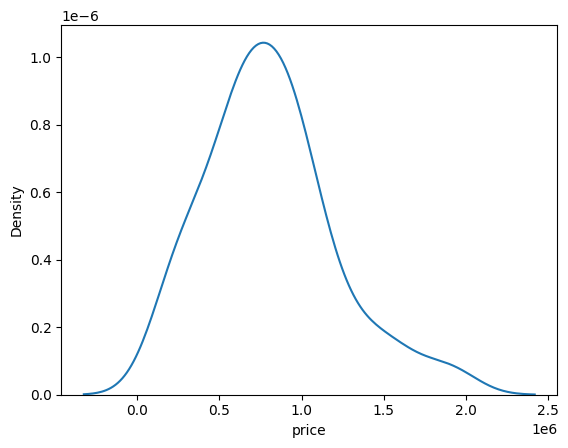

In [ ]:
sns.kdeplot(df['price'])
plt.show()


In [ ]:
df['price'].mean()

np.float64(804979.696969697)

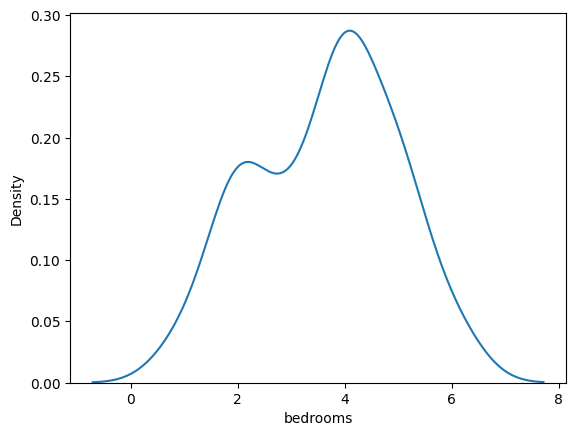

In [ ]:
sns.kdeplot(df['bedrooms'])
plt.show()

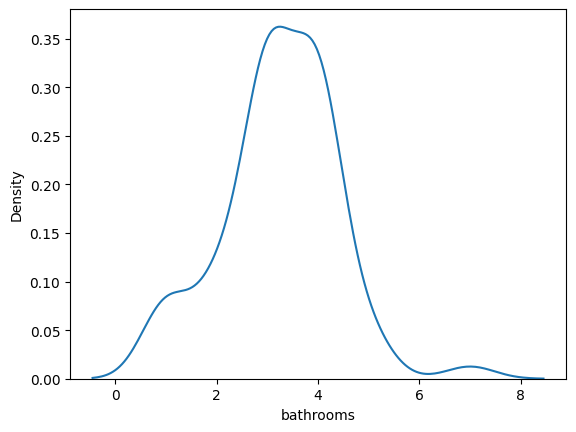

In [ ]:
sns.kdeplot(df['bathrooms'])
plt.show()

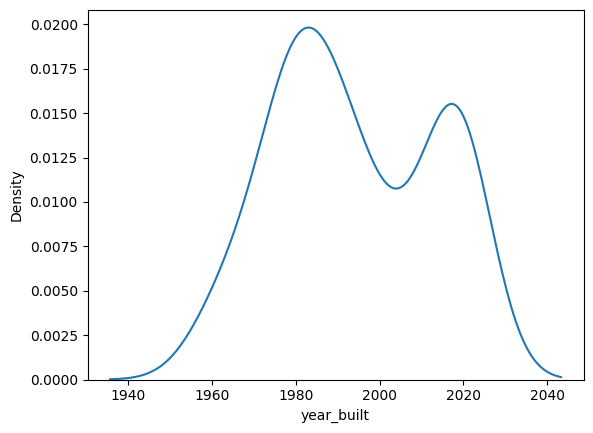

In [ ]:
sns.kdeplot(df['year_built'])
plt.show()

In [ ]:
df['bedrooms'].nunique()

6

In [ ]:
df['bedrooms'].unique()

array([5, 2, 4, 6, 1, 3])

In [ ]:
df['bedrooms'].value_counts()

,count
bedrooms,
4,22
5,14
2,14
3,9
6,4
1,3


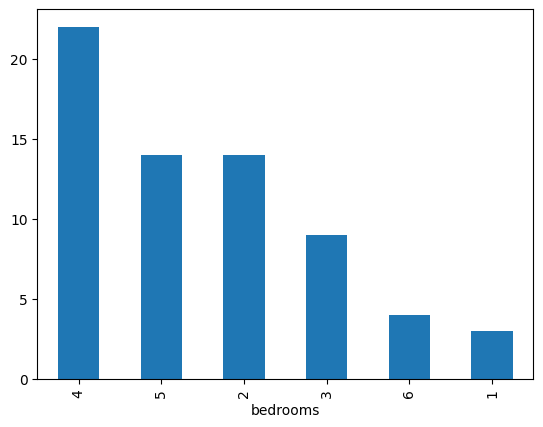

In [ ]:
df['bedrooms'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
df['bathrooms'].nunique()

10

In [ ]:
df['bathrooms'].unique()

array([5. , 4. , 3. , 1. , 3.5, 2. , 2.4, 7. , 2.5, 4.5])

In [ ]:
df['bathrooms'].value_counts()

,count
bathrooms,
3.0,22
4.0,21
2.0,6
1.0,6
5.0,3
3.5,3
4.5,2
2.4,1
7.0,1


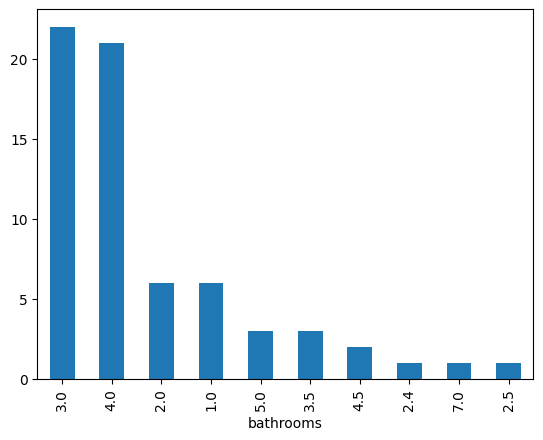

In [ ]:
df['bathrooms'].value_counts().plot(kind='bar')
plt.show()


In [ ]:
df['address'].nunique()

4

In [ ]:
df['address'].nunique()

4

In [ ]:
df['address'].unique()

array(['Centennial, CO 80111', 'Greenwood Village, CO 80111',
       'Englewood, CO 80111', 'Cherry Hills Village, CO 80111'],
      dtype=object)

In [ ]:
df['address'].value_counts()

,count
address,
"Greenwood Village, CO 80111",24
"Centennial, CO 80111",23
"Englewood, CO 80111",18
"Cherry Hills Village, CO 80111",1


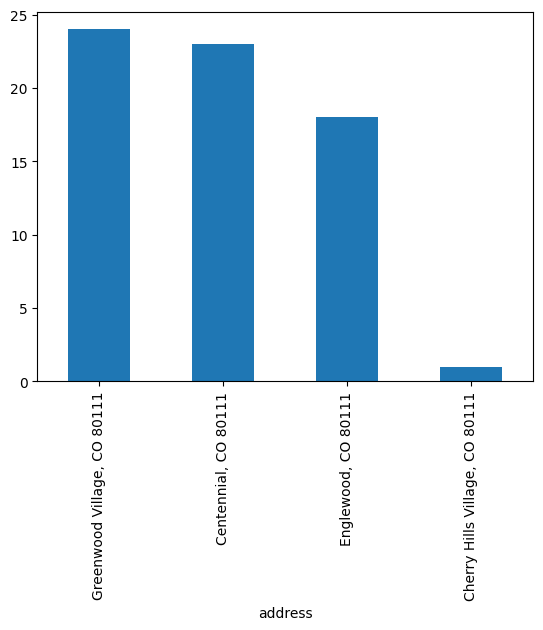

In [ ]:
df['address'].value_counts().plot(kind='bar')
plt.show()


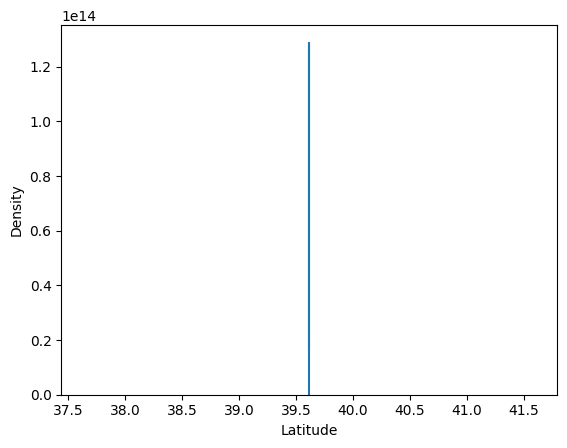

In [ ]:
sns.kdeplot(df['Latitude'])
plt.show()


## BIVARIATE ANALYSIS

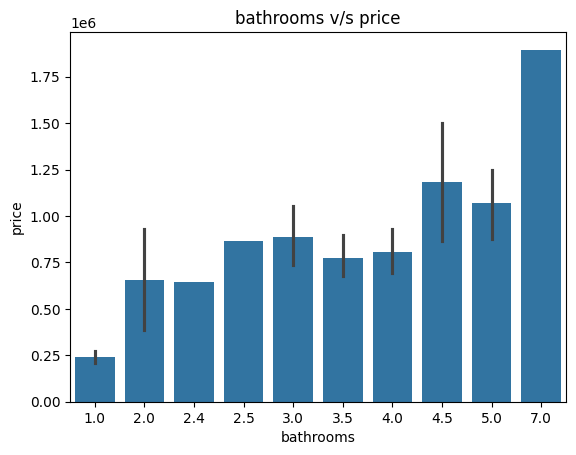

In [ ]:
#bivariate analysis of bathrooms , price
sns.barplot(data=df,x='bathrooms',y='price')
plt.title('bathrooms v/s price')
plt.show()

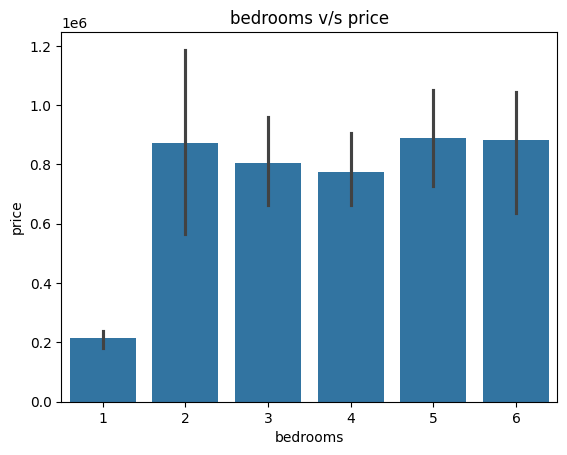

In [ ]:
sns.barplot(data=df,x='bedrooms',y='price')
plt.title('bedrooms v/s price')
plt.show()

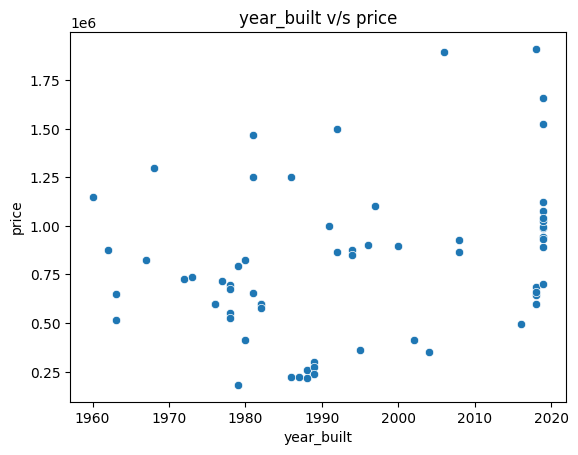

In [ ]:
sns.scatterplot(data=df,x='year_built',y='price')
plt.title('year_built v/s price')
plt.show()


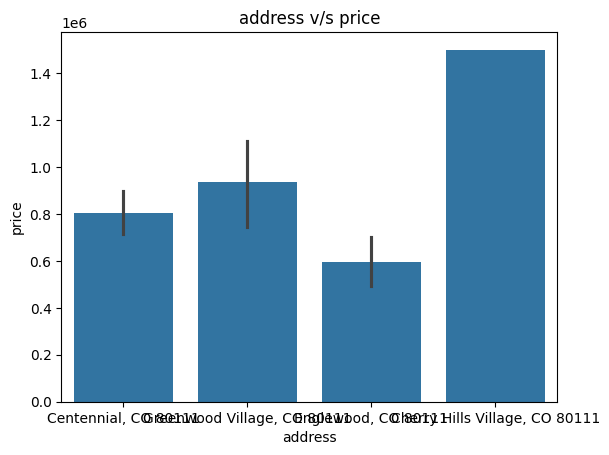

In [ ]:
sns.barplot(data=df,x='address',y='price')
plt.title('address v/s price')
plt.show()

## MULTIVARIATE ANALYSIS

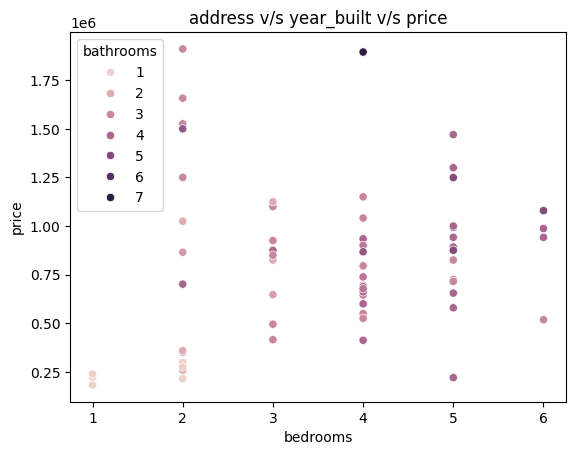

In [ ]:
#multivariate analysis of bedrooms,bathrooms,price
sns.scatterplot(data=df,x='bedrooms',y='price',hue='bathrooms')
plt.title('address v/s year_built v/s price')
plt.show()

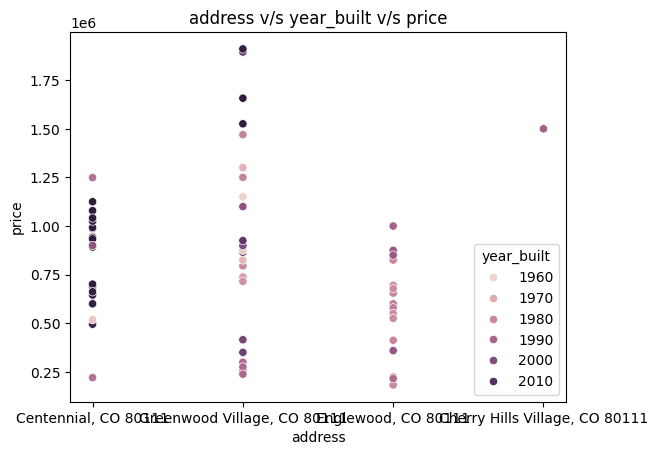

In [ ]:
sns.scatterplot(data=df,x='address',y='price',hue='year_built')
plt.title('address v/s year_built v/s price')
plt.show()


# Feature Engineering


### DATA ENCODING
* Label Encoding
* One Hot Encoding
* Target Encoding

### Target encoding

In [ ]:
tg_address = TargetEncoder(cols=['address'])
df['address'] = tg_address.fit_transform(df['address'], df['address'])

# Handling outlayers

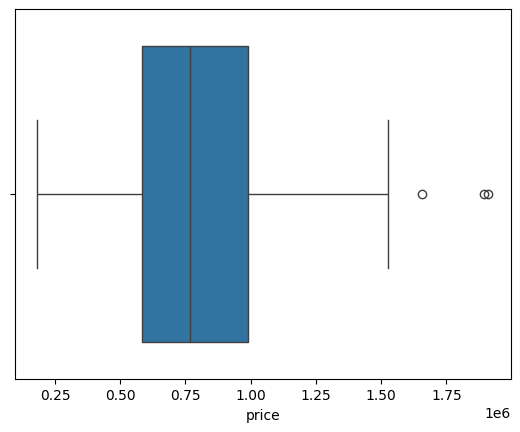

In [ ]:
sns.boxplot(df['price'],orient='h')
plt.show()

In [ ]:
#Handling outlayers of the coloum of 'bmi'
q1 = np.quantile(df['price'],0.25)
q3 = np.quantile(df['price'],0.75)
IQR = q3-q1
min_bound=q1-1.5*IQR
max_bound=q3+1.5*IQR
df.reset_index(drop=True, inplace=True)
for i in range(len(df)):
    if df.loc[i, 'price'] > max_bound:
        df.loc[i, 'price'] = max_bound

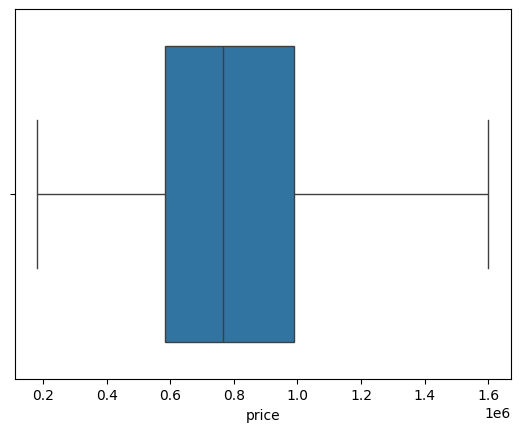

In [ ]:
sns.boxplot(df['price'],orient='h')
plt.show()

In [ ]:
#Handling outlayers of the coloum of 'bmi'
q1 = np.quantile(df['sqft_living'],0.25)
q3 = np.quantile(df['sqft_living'],0.75)
IQR = q3-q1
min_bound=q1-1.5*IQR
max_bound=q3+1.5*IQR
df.reset_index(drop=True, inplace=True)
for i in range(len(df)):
    if df.loc[i, 'sqft_living'] > max_bound:
        df.loc[i, 'sqft_living'] = max_bound

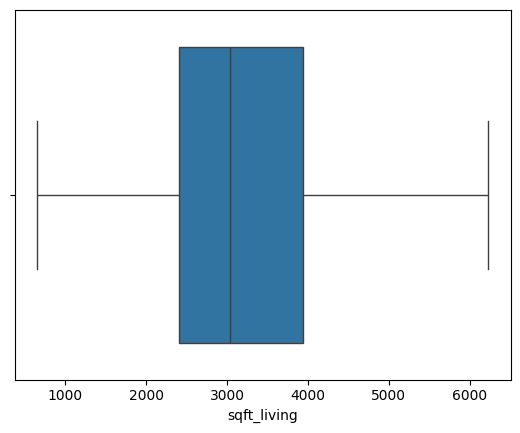

In [ ]:
sns.boxplot(df['sqft_living'],orient='h')
plt.show()

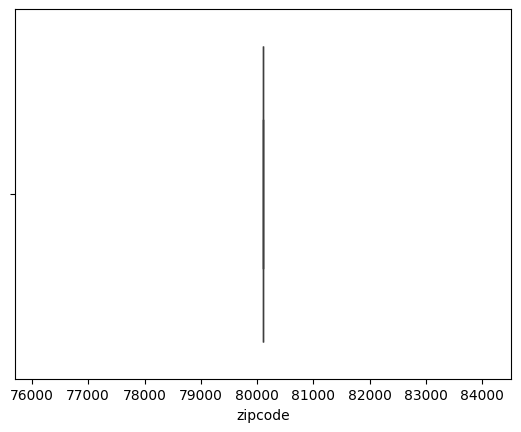

In [ ]:
sns.boxplot(df['zipcode'],orient='h')
plt.show()


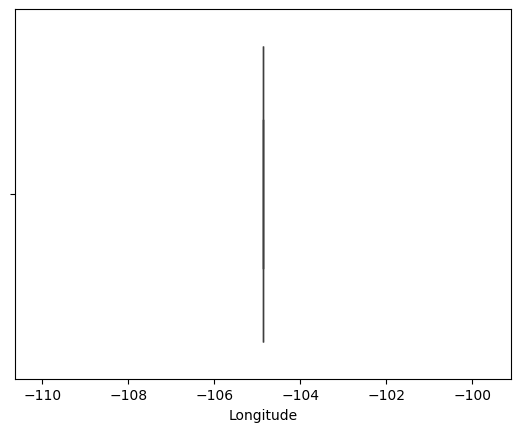

In [ ]:
sns.boxplot(df['Longitude'],orient='h')
plt.show()

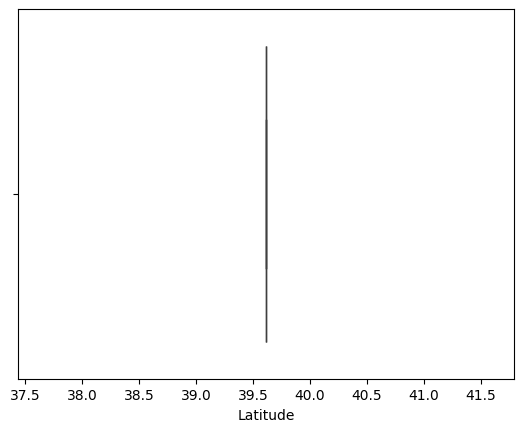

In [ ]:
sns.boxplot(df['Latitude'],orient='h')
plt.show()

# Checking for corelation

In [ ]:
df_cleaned = df.drop(columns=['zipcode', 'Latitude', 'Longitude'])

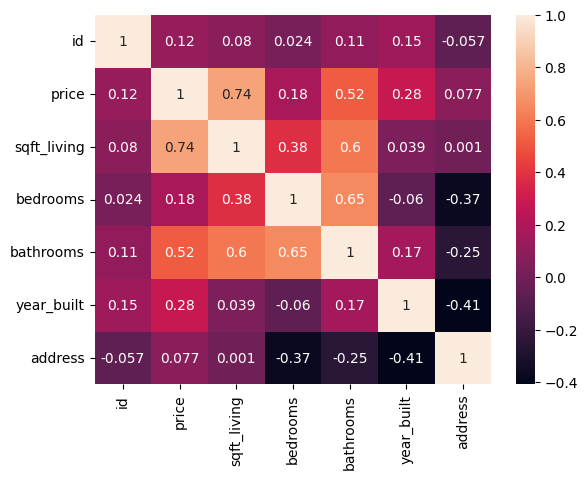

In [ ]:
sns.heatmap(df_cleaned.corr(),annot=True)
plt.show()

# Checking for multicorelation

In [ ]:
df_new=df[['sqft_living','bathrooms','bedrooms','price','year_built']]
df_new

,sqft_living,bathrooms,bedrooms,price,year_built
0,6209.0,5.0,5,1249000.0,1986
1,1422.0,4.0,5,220000.0,1986
2,5614.0,3.0,2,1250000.0,1981
3,2785.0,3.0,4,599900.0,1982
4,3449.0,4.0,6,986950.0,2019
...,...,...,...,...,...
61,5292.0,4.0,5,1470000.0,1981
62,3049.0,4.0,4,661559.0,2018
63,3593.0,3.0,5,715000.0,1977
64,2334.0,3.0,4,524900.0,1978


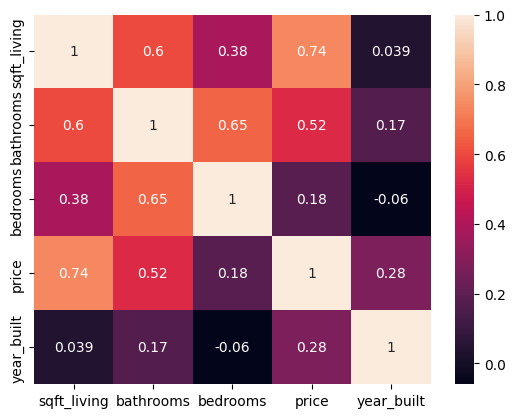

In [ ]:
sns.heatmap(df_new.corr(),annot=True)
plt.show()

In [ ]:
selected=['sqft_living','bathrooms','year_built','bedrooms','price']

In [ ]:
new=df_new[selected]
new

,sqft_living,bathrooms,year_built,bedrooms,price
0,6209.0,5.0,1986,5,1249000.0
1,1422.0,4.0,1986,5,220000.0
2,5614.0,3.0,1981,2,1250000.0
3,2785.0,3.0,1982,4,599900.0
4,3449.0,4.0,2019,6,986950.0
...,...,...,...,...,...
61,5292.0,4.0,1981,5,1470000.0
62,3049.0,4.0,2018,4,661559.0
63,3593.0,3.0,1977,5,715000.0
64,2334.0,3.0,1978,4,524900.0


# Data scaling

In [ ]:
price_std = StandardScaler()
df_new['price'] = price_std.fit_transform(df_new[['price']])

In [ ]:
bedrooms_std = StandardScaler()
df_new['bedrooms'] = bedrooms_std.fit_transform(df_new[['bedrooms']])

In [ ]:
yearbuilt_std = StandardScaler()
df_new['year_built'] = yearbuilt_std.fit_transform(df_new[['year_built']])

In [ ]:
bathrooms_std = StandardScaler()
df_new['bathrooms'] = bathrooms_std.fit_transform(df_new[['bathrooms']])

In [ ]:
sqftliving_std = StandardScaler()
df_new['sqft_living'] =sqftliving_std.fit_transform(df_new[['sqft_living']])

#model building


In [ ]:
df_new

,sqft_living,bathrooms,bedrooms,price,year_built
0,2.181032,1.583146,1.040897,1.249214,-0.435758
1,-1.253212,0.679274,1.040897,-1.581795,-0.435758
2,1.754173,-0.224599,-1.249077,1.251965,-0.705047
3,-0.275381,-0.224599,0.277573,-0.536605,-0.651189
4,0.200979,0.679274,1.804222,0.528256,1.341548
...,...,...,...,...,...
61,1.523167,0.679274,1.040897,1.857234,-0.705047
62,-0.085985,0.679274,0.277573,-0.366968,1.287690
63,0.304286,-0.224599,1.040897,-0.219940,-0.920478
64,-0.598933,-0.224599,0.277573,-0.742947,-0.866620
